## 배경전환 크로마키사진

원본 고양이 이미지 크기: (1851, 2776, 3)
배경(사막) 이미지 크기: (4000, 6000, 3)


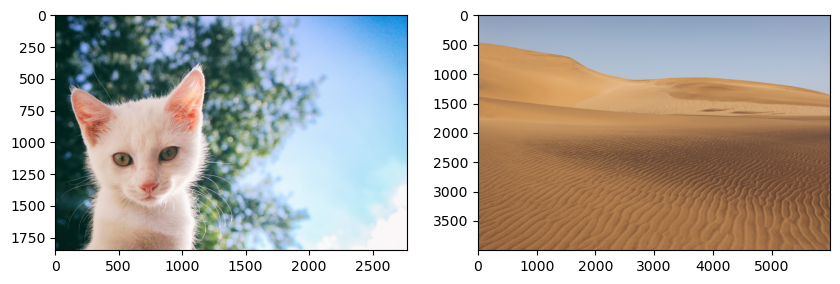

In [4]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

cat_img_path = "images/cat.jpg"  # 고양이 이미지를 준비해주세요
sand_img_path = "images/sand.jpg"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [6]:
from torchvision.models.segmentation import  DeepLabV3_ResNet101_Weights

model = deeplabv3_resnet101(weights=DeepLabV3_ResNet101_Weights.DEFAULT).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [7]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (1851, 2776)


In [8]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


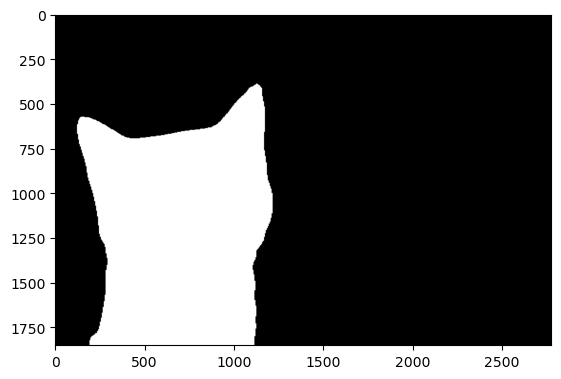

In [9]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

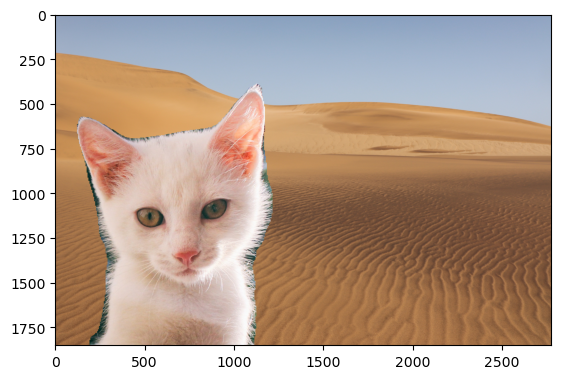

In [10]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

## 아웃포커싱 효과가 적용된 인물모드 사진

이미지 크기: (3679, 4905, 3)


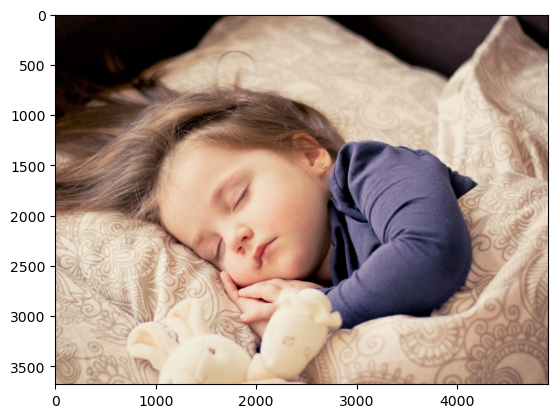

In [12]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

img_path = "images/person.jpg"

img = cv2.imread(img_path)

print(f"이미지 크기: {img.shape}")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [13]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

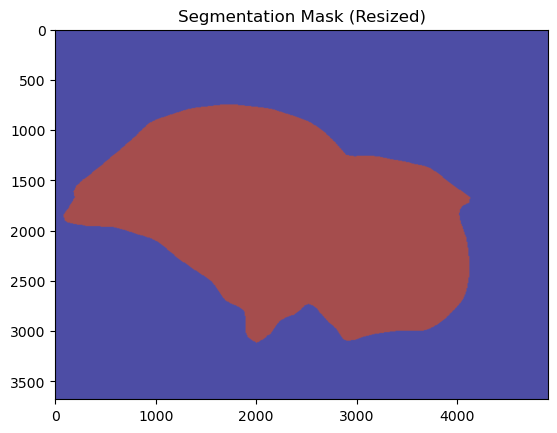

In [14]:
input_tensor = transform(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

    output_predictions_resized = cv2.resize(output_predictions, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

    plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [17]:
LABEL_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tv'
]
len(LABEL_NAMES)

21

In [15]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0, 15], dtype=uint8)

In [18]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
person


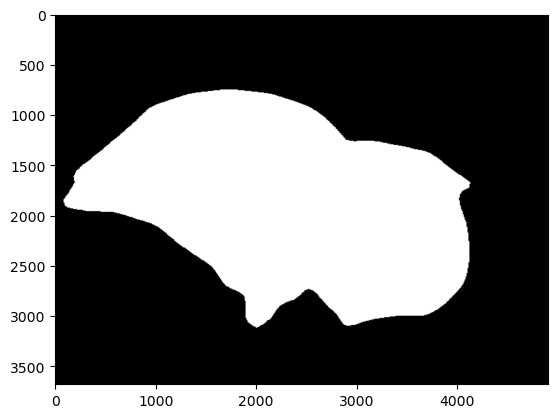

In [19]:
seg_map = (output_predictions_resized == 15)  # 클래스 ID 15 (사람)
img_mask = seg_map.astype(np.uint8) * 255  # 255 값으로 변환
color_mask = cv2.applyColorMap(img_mask, cv2.COLORMAP_JET)

plt.imshow(img_mask, cmap='gray')  # 흑백으로 표시
plt.show()

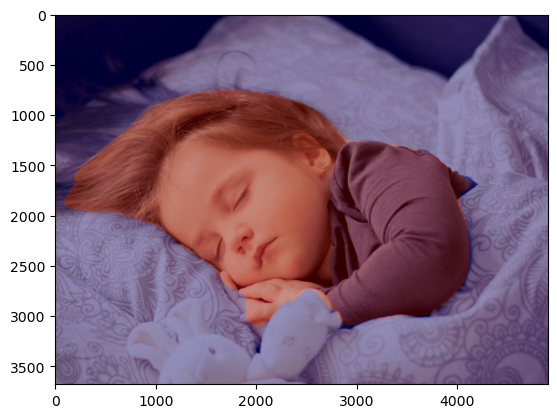

In [20]:
img_show = cv2.addWeighted(img, 0.6, color_mask, 0.4, 0.0)

plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
plt.show()

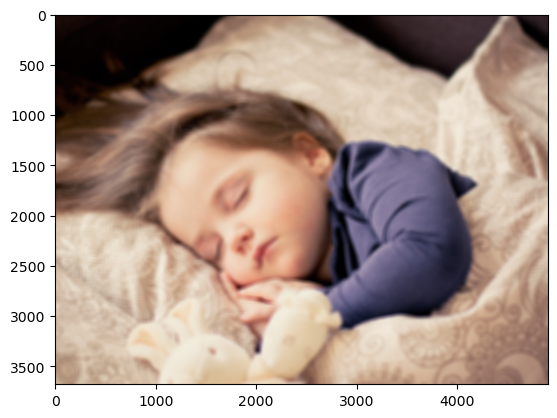

In [28]:
img_blur = cv2.blur(img, (50, 50)) #해당 이미지의 배경이 베이지색이라 그런지, blur 처리의 시각적 효과가 강하지 않아서, 파라미터를 크게 조정

plt.imshow(cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB))
plt.show()

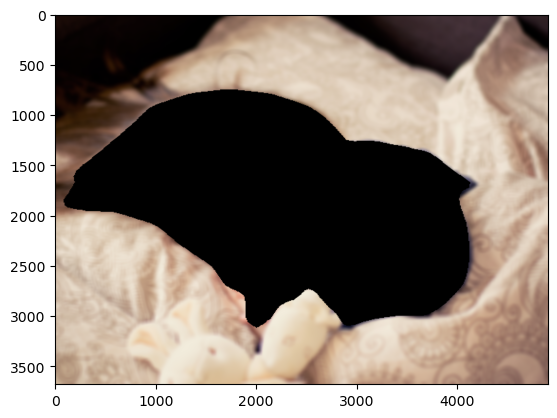

In [29]:
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
img_bg_mask = cv2.bitwise_not(img_mask_color)
img_bg_blur = cv2.bitwise_and(img_blur, img_bg_mask)
plt.imshow(cv2.cvtColor(img_bg_blur, cv2.COLOR_BGR2RGB))
plt.show()

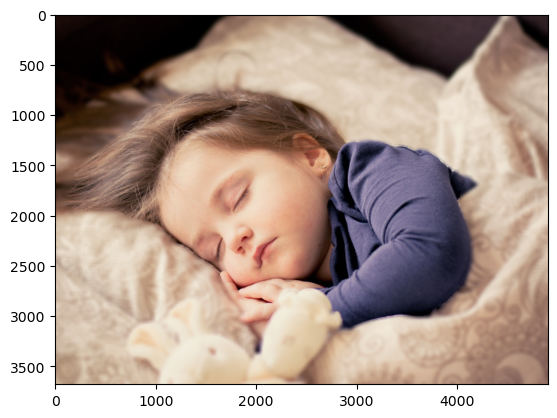

In [30]:
img_concat = np.where(img_mask_color==255, img, img_bg_blur)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

## 아웃포커싱 효과가 적용된 동물 사진 
(인물사진에서 흑백 표시, 배경흐리게 하기 등의 시각화 과정을 모두 상세히 진행하였으므로,  
동물사진의 경우 생략하고 핵심 코드만 작성하겠습니다.)

이미지 크기: (3719, 5578, 3)


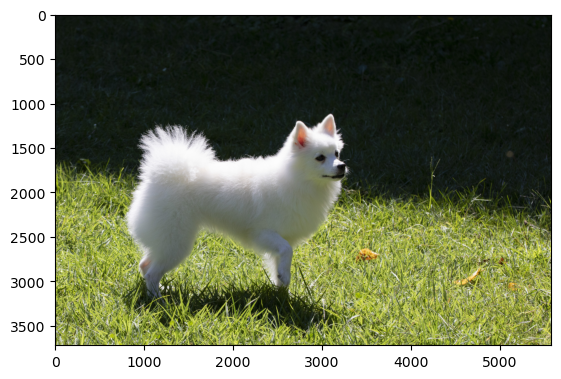

In [31]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

img_path = "images/dog.jpg"

img = cv2.imread(img_path)

print(f"이미지 크기: {img.shape}")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

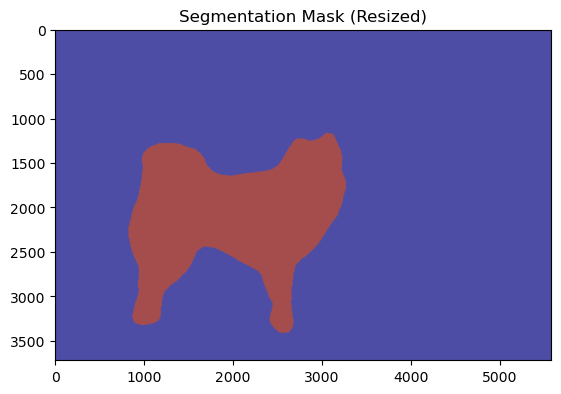

In [32]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

input_tensor = transform(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

    output_predictions_resized = cv2.resize(output_predictions, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

    plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [34]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

array([ 0, 17], dtype=uint8)

In [35]:
for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
sheep


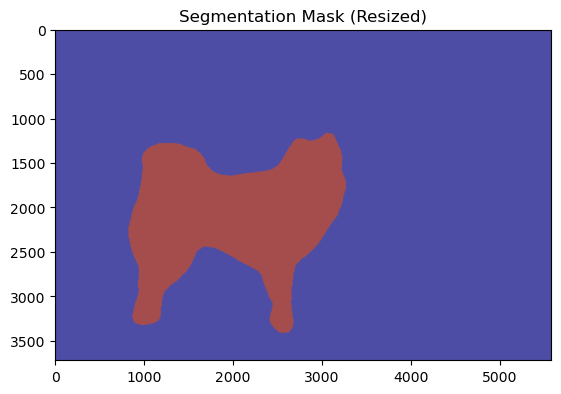

In [41]:
# dog를 sheep으로 잘못 분류함 -> 모델의 가중치를 COCO로 학습된 가중치로 변경
weights = DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet101(weights=weights).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기 (고정)
    T.ToTensor(),
])

input_tensor = transform(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

    output_predictions_resized = cv2.resize(output_predictions, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

    plt.imshow(output_predictions_resized, cmap="jet", alpha=0.7)
plt.title("Segmentation Mask (Resized)")
plt.show()

In [42]:
unique_classes = np.unique(output_predictions_resized)
unique_classes

for class_id in unique_classes:
    print(LABEL_NAMES[class_id])

background
sheep


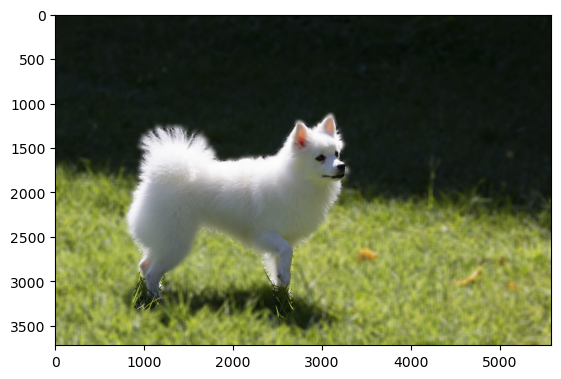

In [49]:
# COCO데이터로 학습했음에도 여전히 sheep으로 잘못 분류하고 있지만,
# 동물 사진을 아웃포커싱하는 과제는 수행할 수 있으며, 모델을 재학습할 여건이 안되므로 
# 다음 단계 진행 (오분류된 영역 17번을 마스크로 추출)
seg_map = (output_predictions_resized == 17)
img_mask = seg_map.astype(np.uint8) * 255

img_blur = cv2.blur(img, (50, 50))

img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)
img_bg_mask = cv2.bitwise_not(img_mask_color)
img_bg_blur = cv2.bitwise_and(img_blur, img_bg_mask)

img_concat = np.where(img_mask_color==255, img, img_bg_blur)
plt.imshow(cv2.cvtColor(img_concat, cv2.COLOR_BGR2RGB))
plt.show()

## 제작한 인물모드 사진들에서 나타나는 문제점을 지적한 사진들
![아웃포커싱 효과가 적용된 인물 사진](images/인물사진.png)
![아웃포커싱 효과가 적용된 동물 사진](images/동물사진.png)
![배경전환 크로마키사진](images/배경전환크로마키.png)

## 위의 문제점 개선 솔루션 제시

### 우선, 위의 문제점들을 정리하면 아래와 같다.
1. 인물 사진: 머리카락, 손가락 등 경계가 부자연스럽게 잘리는 문제  
  → 머리카락: 일부가 사진상에서 더 멀리 있고 입체감없이 배경과 아예 붙어있는 모양새라 제대로 탐지가 안되는 것 같다  
  → 손가락, 옷자락: 경계와 맞닿아있는데, 그 영역이 얇은? 좁은 부분이라 구분이 잘 안되는 것 같다
2. 동물 사진, 배경 전환 크로마키: 털과 같은 세밀한 구조가 있는 대상은 경계 정보가 뚜렷하지 않은 문제  
  → 털 사이사이의 경계까지 탐지하기엔 민감도가 낮아서, 혹은 이런 패턴을 학습하지 못해서 경계 구분을 제대로 못하고 있는 것 같다
3. 배경전환 크로마키: foreground와 background의 분리가 부자연스러움  
   → smooth blur처리가 필요할 것 같다 (단, 2번의 고양이 털 문제를 해결한 뒤에)

### 개선안
1. 인물 사진: Struct2Depth 계열의 깊이 추정 + 경계 보정
  - 아이디어: struct2depth를 이용해 인물 사진이라는 특징을 더 자연스럽게 살린다
  - Struct2Depth: 단안 영상으로부터 깊이 및 자기운동 정보를 추출하는 비지도 학습 방법으로, 3D 장면과 개별 객체의 움직임을 모델링한다
  - 얼굴.어깨.배경 사이의 상대적 거리 차이를 이용해 더 자연스러운 아웃포커싱을 인물 사진에 적용한다
  - 인물의 눈.코.입 주변처럼 인물 사진의 핵심 부분은 더 높은 가중치를 주고,
  - 얇아서 감지가 잘 안되었던 **손가락 끝, 옷자락 끝** 처럼 얇은 영역과 **일부 머리카락**에 대해서는 **edge-aware refinement**로 후처리를 진행한다
2. 동물 사진: 저수준 특징 보강 + 경계/텍스처 민감도 강화
  - 아이디어: 저수준 특징, 텍스터, 엣지 정보를 더 강하게 쓰는 구조를 도입
  - 얕은 레이어의 feature를 더 많이 사용하는 U-Net/FPN 구조를 사용한다
  - boundary loss, edge loss, trimap refinement를 추가한다
  - 털이 많은 동물 데이터로 별도 fine-tuning을 진행해 이러한 패턴도 잘 감지할 수 있는 모델을 사용한다
  - mask를 한 번에 끝내지 않고, coarse-to-fine 방식으로 점진적으로 정밀화한다
3. 배경전환 크로마키: 단일 마스크가 아닌 depth-aware compositing
  - 아이디어: 현재 진행된 마스크 상태에서 깊이 정보를 만들어 거리 기반으로 background와 foreground를 자연스럽게 연결한다
  - depth-aware compositing을 사용한다
  - 즉, 픽셀별 깊이 맵을 만들어서 배경 블러를 거리 기반으로 후처리한다

### 파이프라인
1. 입력 이미지 수집
2. 대상 분류: 인물 / 동물 / 일반 배경
3. 인물인 경우, Struct2Depth 기반 depth estimation 수행  
   동물인 경우, boundary-aware segmentation 모델 수행
4. depth map과 mask를 결합하여 confidence map 생성
5. edge-aware refinement 로 머리카락, 털, 손끝 등 경계 보정
6. 최종적으로 depth 기반 blur 또는 compositing 적용